# LaCAM + PIBT + primitive demo
This notebook builds the dependency-free C++ planner, runs the crossing example, and displays the generated GIF inline.

In [ ]:
from pathlib import Path    
import subprocess, sys, yaml
from IPython.display import Image, display
REPO = Path('..').resolve()
sys.path.insert(0, str(REPO / 'python'))
from lacam_primitive_viz import plan_and_animate

In [2]:
subprocess.run(['cmake', '-S', str(REPO), '-B', str(REPO / 'build'), '-DCMAKE_BUILD_TYPE=Release'], check=True)
subprocess.run(['cmake', '--build', str(REPO / 'build'), '-j2'], check=True)

-- Configuring done (0.0s)
-- Generating done (0.0s)
-- Build files have been written to: /home/kakitsu/tel/lacam_primitive/build
[ 60%] Built target lacam_primitive_core
[100%] Built target lacam_primitive
[100%] Built target lacam_primitive_tests


CompletedProcess(args=['cmake', '--build', '/home/kakitsu/tel/lacam_primitive/build', '-j2'], returncode=0)

In [29]:
artifacts = plan_and_animate(
    REPO,
    REPO / 'examples' / 'example.yaml',
    REPO / "outputs" / "notebook_waypoints",
    time_limit_ms=1000,
    transition_cache=True,
    candidate_cache=True,
    ara_star=True,
    pixels_per_cell=12,
    waypoint_only=True,
)

solution improved: cost=8.4 weight=5 search_ms=18.1971
solution improved: cost=6.2 weight=2.4 search_ms=56.2828
solution improved: cost=5.8 weight=1.6 search_ms=73.8228
solution improved: cost=5.6 weight=1.2 search_ms=313.469
precompute static: 77.6734 ms (primitive/collision=53.2255, transition_cache=24.4472)
precompute query: 5.19057 ms (candidate_cache=5.18013)
search: 642.563 ms
warm request: 647.754 ms
cold total: 725.427 ms
modes: transition_cache=on candidate_cache=on ara_star=on
cache stats: transition 930402/930402 hits, candidate 122593/122593 hits, expanded_nodes=1539
Final solution cost: 5.6, search: 642.563 ms



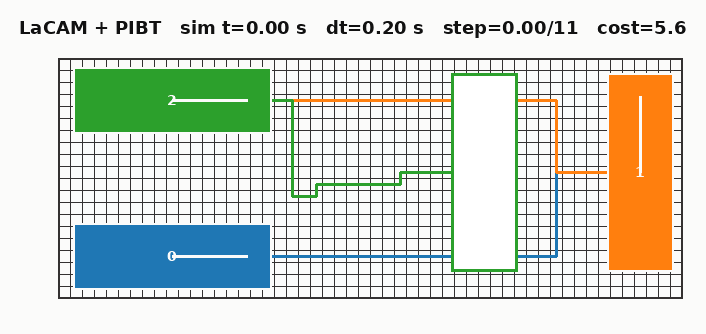

In [30]:
display(Image(filename=str(artifacts['animation'])))

In [7]:
artifacts = plan_and_animate(
    REPO,
    REPO / 'examples' / 'example.yaml',
    REPO / "outputs" / "smooth",
    time_limit_ms=10000,
    transition_cache=True,
    candidate_cache=True,
    ara_star=True,
    pixels_per_cell=12,
)

solution improved: cost=7.2 weight=5 search_ms=16.5403
solution improved: cost=5.8 weight=2 search_ms=60.2443
solution improved: cost=5.6 weight=1 search_ms=1112.77
precompute static: 91.7201 ms (primitive/collision=65.6964, transition_cache=26.0231)
precompute query: 5.5685 ms (candidate_cache=5.55805)
search: 1113.07 ms
warm request: 1118.64 ms
cold total: 1210.36 ms
modes: transition_cache=on candidate_cache=on ara_star=on
cache stats: transition 1584593/1584593 hits, candidate 183874/183874 hits, expanded_nodes=2167
Final solution cost: 5.6, search: 1113.07 ms



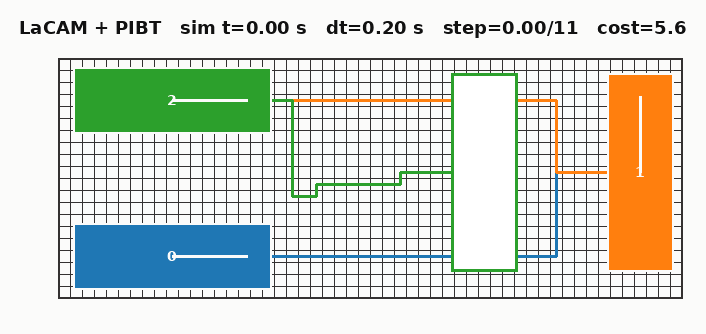

In [8]:
display(Image(filename=str(artifacts['animation'])))

In [5]:
with artifacts['solution'].open(encoding='utf-8') as stream:
    result = yaml.safe_load(stream)
result['improvements'], result['cost']

([{'elapsed_ms': 1.391816, 'cost': 3.4, 'weight': 3}], 3.4)